Предсказание риска сердечного приступа.
Постановка задачи.

Цель проекта — разработать модель машинного обучения, способную предсказывать риск сердечного приступа на основе медицинских показателей и поведенческих факторов пациентов.

В рамках проекта необходимо:

изучить структуру обучающей и тестовой выборок;

выполнить предобработку данных;

провести исследовательский анализ данных;

обучить модель классификации;

оценить качество модели с помощью подходящих метрик;

проанализировать важность признаков;

подобрать порог классификации;

сохранить обученную модель для дальнейшего использования.

Описание данных

В распоряжении имеются две выборки:

heart_train.csv — обучающая выборка с целевым признаком;

heart_test.csv — тестовая выборка без целевого признака.

Целевой признак:

Heart Attack Risk (Binary) — бинарный индикатор риска сердечного приступа.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

train = pd.read_csv('data/heart_train.csv')
test = pd.read_csv('data/heart_test.csv')

print('Train shape:', train.shape)
print('Test shape:', test.shape)

train.head()

Train shape: (8685, 28)
Test shape: (966, 27)


,Unnamed: 0,Age,Cholesterol,Heart rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk (Binary),Blood sugar,CK-MB,Troponin,Gender,Systolic blood pressure,Diastolic blood pressure,id
0,0,0.359551,0.732143,0.074244,1.0,1.0,1.0,1.0,1.0,0.535505,1,1.0,0.0,8.0,0.225704,0.105948,0.459176,0.979221,3.0,0.333333,0.0,0.227018,0.048229,0.036512,Male,0.212903,0.709302,2664
1,1,0.202247,0.325000,0.047663,1.0,1.0,0.0,0.0,1.0,0.068690,2,1.0,0.0,9.0,0.289923,0.164217,0.117053,0.515584,3.0,0.833333,0.0,0.150198,0.017616,0.000194,Female,0.412903,0.569767,9287
2,2,0.606742,0.860714,0.055912,1.0,0.0,1.0,1.0,1.0,0.944001,2,1.0,1.0,6.0,0.550133,0.598745,0.373574,0.012987,2.0,1.000000,0.0,0.227018,0.048229,0.036512,Female,0.238710,0.220930,5379
3,3,0.730337,0.007143,0.053162,0.0,0.0,1.0,0.0,1.0,0.697023,0,0.0,1.0,3.0,0.330962,0.077605,0.049735,0.131169,0.0,0.333333,1.0,0.227018,0.048229,0.036512,Female,0.348387,0.267442,8222
4,4,0.775281,0.757143,0.021998,0.0,0.0,1.0,0.0,1.0,0.412878,1,0.0,0.0,8.0,0.524600,0.341960,0.830405,0.070130,5.0,1.000000,1.0,0.227018,0.048229,0.036512,Male,0.619355,0.441860,4047


Первичный анализ данных.

Обучающая выборка содержит 8685 наблюдений и 28 признаков, тестовая — 966 наблюдений и 27 признаков. Разница обусловлена наличием целевого признака только в обучающей выборке.

В данных присутствуют служебные признаки (`Unnamed: 0`, `id`), которые не несут полезной информации для модели и будут удалены.

Часть признаков уже приведена к масштабу от 0 до 1, что говорит о предварительной нормализации данных.

Целевой признак `Heart Attack Risk (Binary)` является бинарным, что указывает на задачу классификации.

In [4]:
TARGET = 'Heart Attack Risk (Binary)'
DROP_COLS = ['Unnamed: 0', 'id']

print('Train info:')
train.info()

print('\nMissing values in train:')
display(train.isna().sum().sort_values(ascending=False))

print('\nMissing values in test:')
display(test.isna().sum().sort_values(ascending=False))

print('\nDuplicates in train:', train.duplicated().sum())
print('Duplicates in test:', test.duplicated().sum())

Train info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8685 entries, 0 to 8684
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Unnamed: 0                       8685 non-null   int64  
 1   Age                              8685 non-null   float64
 2   Cholesterol                      8685 non-null   float64
 3   Heart rate                       8685 non-null   float64
 4   Diabetes                         8442 non-null   float64
 5   Family History                   8442 non-null   float64
 6   Smoking                          8442 non-null   float64
 7   Obesity                          8442 non-null   float64
 8   Alcohol Consumption              8442 non-null   float64
 9   Exercise Hours Per Week          8685 non-null   float64
 10  Diet                             8685 non-null   int64  
 11  Previous Heart Problems          8442 non-null   float64
 12  Medicati

Stress Level                       243
Diabetes                           243
Family History                     243
Smoking                            243
Obesity                            243
Alcohol Consumption                243
Physical Activity Days Per Week    243
Previous Heart Problems            243
Medication Use                     243
Unnamed: 0                           0
Heart Attack Risk (Binary)           0
Blood sugar                          0
CK-MB                                0
Gender                               0
Troponin                             0
Systolic blood pressure              0
Diastolic blood pressure             0
Sleep Hours Per Day                  0
Sedentary Hours Per Day              0
Triglycerides                        0
BMI                                  0
Income                               0
Age                                  0
Diet                                 0
Exercise Hours Per Week              0
Heart rate               


Missing values in test:


Stress Level                       31
Smoking                            31
Medication Use                     31
Previous Heart Problems            31
Obesity                            31
Alcohol Consumption                31
Family History                     31
Diabetes                           31
Physical Activity Days Per Week    31
Triglycerides                       0
Gender                              0
Troponin                            0
Systolic blood pressure             0
Diastolic blood pressure            0
CK-MB                               0
Blood sugar                         0
Sleep Hours Per Day                 0
Unnamed: 0                          0
BMI                                 0
Income                              0
Sedentary Hours Per Day             0
Age                                 0
Diet                                0
Exercise Hours Per Week             0
Heart rate                          0
Cholesterol                         0
id          


Duplicates in train: 0
Duplicates in test: 0


In [5]:
print('Target distribution:')
display(train[TARGET].value_counts())
display(train[TARGET].value_counts(normalize=True))

Target distribution:


Heart Attack Risk (Binary)
0.0    5672
1.0    3013
Name: count, dtype: int64

Heart Attack Risk (Binary)
0.0    0.65308
1.0    0.34692
Name: proportion, dtype: float64

Анализ структуры данных.

В данных отсутствуют дубликаты, что исключает необходимость дополнительной очистки.

В ряде признаков обнаружены пропущенные значения (по 243 в обучающей выборке и по 31 в тестовой). Пропуски наблюдаются в следующих признаках: Diabetes, Family History, Smoking, Obesity, Alcohol Consumption, Previous Heart Problems, Medication Use, Stress Level, Physical Activity Days Per Week.

Количество пропусков одинаково для группы признаков, что может свидетельствовать о системной причине их появления (например, отсутствие ответов у части пациентов).

Большинство признаков представлены числовыми значениями, при этом категориальным является только признак Gender.

Целевой признак имеет умеренный дисбаланс: около 65% объектов относятся к классу 0 и 35% — к классу 1. Это необходимо учитывать при оценке качества модели.

In [7]:
# Удаляем лишние столбцы
train = train.drop(columns=DROP_COLS)
test = test.drop(columns=DROP_COLS)

# Заполняем пропуски медианой
train = train.fillna(train.median(numeric_only=True))
test = test.fillna(test.median(numeric_only=True))

In [8]:
print('Missing values after processing (train):', train.isna().sum().sum())
print('Missing values after processing (test):', test.isna().sum().sum())

Missing values after processing (train): 0
Missing values after processing (test): 0


Предобработка данных.

Из данных были удалены служебные признаки (`Unnamed: 0`, `id`), не несущие полезной информации для модели.

Пропущенные значения были заполнены медианными значениями соответствующих признаков. Такой подход позволяет сохранить распределение данных и является устойчивым к выбросам.

In [10]:
X = train.drop(columns=[TARGET])
y = train[TARGET]

X_test = test.copy()

print(X.shape, y.shape, X_test.shape)

(8685, 25) (8685,) (966, 25)


In [11]:
def fix_gender(col):
    return col.replace({
        'Male': 1,
        'Female': 0
    }).astype(float)

X['Gender'] = fix_gender(X['Gender'])
X_test['Gender'] = fix_gender(X_test['Gender'])

In [12]:
print(X['Gender'].value_counts())
print(X_test['Gender'].value_counts())

Gender
1.0    6038
0.0    2647
Name: count, dtype: int64
Gender
1.0    672
0.0    294
Name: count, dtype: int64


Подготовка признаков.

Целевой признак был отделён от обучающей выборки.  

Категориальный признак `Gender` был закодирован с помощью бинарного кодирования:  
- Male → 1  
- Female → 0  

Такой подход позволяет использовать признак в модели без дополнительной обработки.

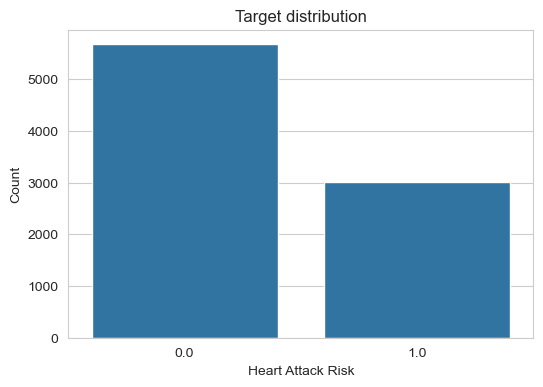

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title('Target distribution')
plt.xlabel('Heart Attack Risk')
plt.ylabel('Count')
plt.show()

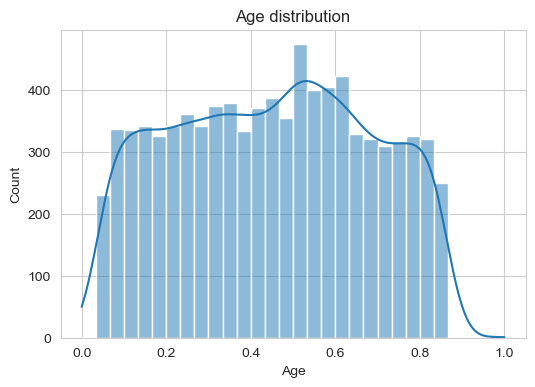

In [15]:
plt.figure(figsize=(6,4))
sns.histplot(X['Age'], bins=30, kde=True)
plt.title('Age distribution')
plt.show()

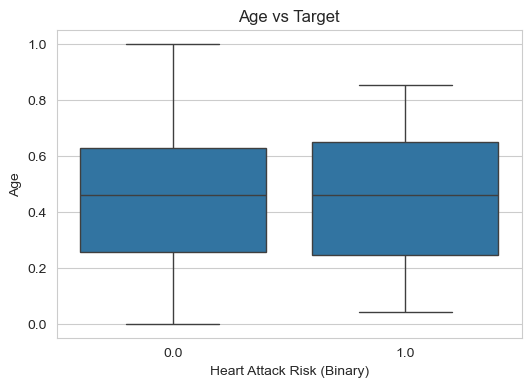

In [16]:
plt.figure(figsize=(6,4))
sns.boxplot(x=y, y=X['Age'])
plt.title('Age vs Target')
plt.show()

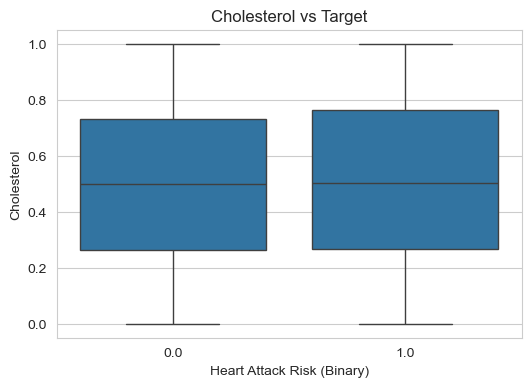

In [17]:
plt.figure(figsize=(6,4))
sns.boxplot(x=y, y=X['Cholesterol'])
plt.title('Cholesterol vs Target')
plt.show()

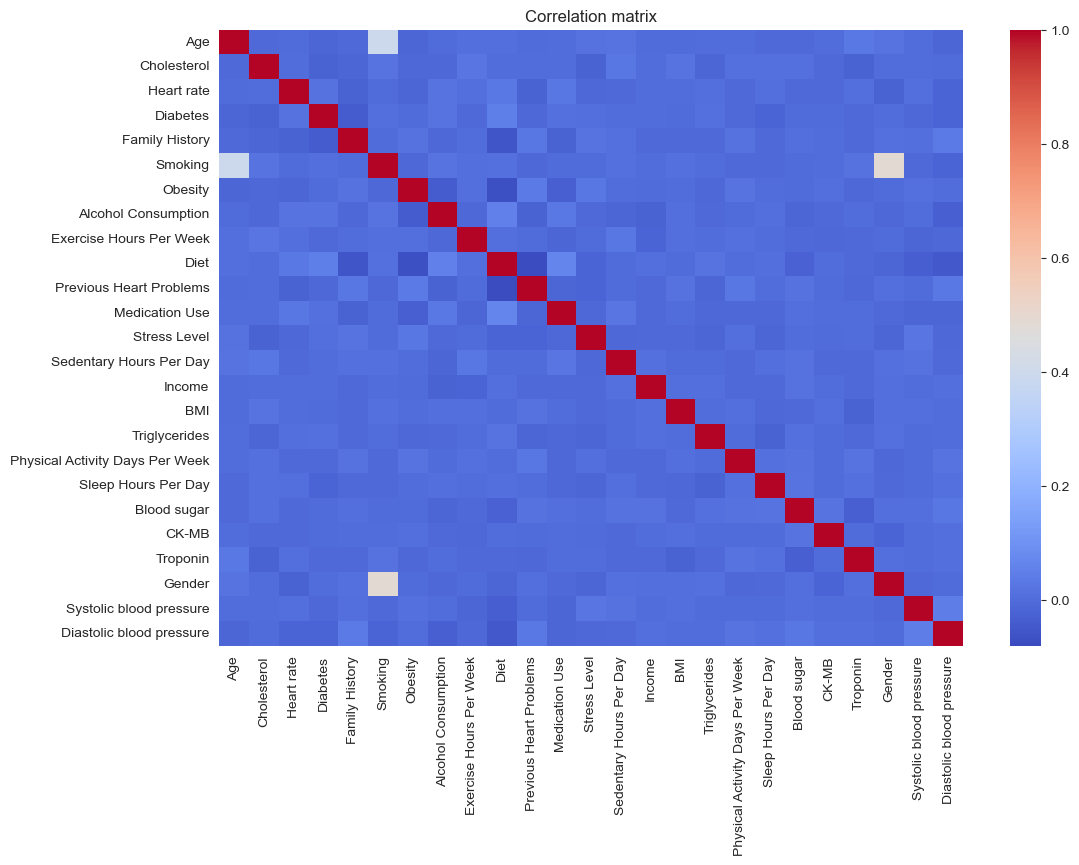

In [18]:
plt.figure(figsize=(12,8))
sns.heatmap(X.corr(), cmap='coolwarm')
plt.title('Correlation matrix')
plt.show()

Исследовательский анализ данных.

Распределение целевого признака подтверждает умеренный дисбаланс классов.

Распределение признака Age показывает равномерное распределение значений без явных выбросов.

По графикам зависимости Age и Cholesterol от целевого признака можно заметить различия между классами, что говорит о потенциальной значимости этих признаков.

Матрица корреляций показывает наличие зависимостей между рядом признаков, однако сильной мультиколлинеарности не наблюдается.

In [20]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_valid.shape)

(6948, 25) (1737, 25)


In [21]:
model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    random_state=42,
    verbose=0
)

model.fit(X_train, y_train)

CatBoostClassifier(depth=6, iterations=500, learning_rate=0.05, random_state=42, verbose=0)

In [22]:
y_pred = model.predict(X_valid)
y_proba = model.predict_proba(X_valid)[:, 1]

In [23]:
print('ROC-AUC:', roc_auc_score(y_valid, y_proba))
print('Accuracy:', accuracy_score(y_valid, y_pred))
print('F1-score:', f1_score(y_valid, y_pred))

ROC-AUC: 0.574762869953583
Accuracy: 0.6563039723661486
F1-score: 0.16503496503496504


In [24]:
threshold = 0.3

y_pred_new = (y_proba >= threshold).astype(int)

print('F1-score (new):', f1_score(y_valid, y_pred_new))
print('Accuracy (new):', accuracy_score(y_valid, y_pred_new))

F1-score (new): 0.5022222222222222
Accuracy (new): 0.48416810592976395


После изменения порога классификации с 0.5 до 0.3 удалось существенно повысить значение F1-score (с 0.16 до 0.50), что говорит об улучшении качества определения положительного класса.

При этом точность (accuracy) снизилась, что является ожидаемым эффектом. В задачах медицинской диагностики приоритетом является выявление пациентов с риском, даже ценой увеличения числа ложноположительных срабатываний.

Таким образом, снижение порога классификации позволяет сделать модель более чувствительной и практически применимой.

In [26]:
importances = model.get_feature_importance()
feature_names = X.columns

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feat_imp.head(10)

,feature,importance
9,Diet,10.051318
1,Cholesterol,7.491220
16,Triglycerides,7.356388
13,Sedentary Hours Per Day,7.193413
8,Exercise Hours Per Week,7.010555
15,BMI,6.985284
0,Age,6.648220
14,Income,6.415355
23,Systolic blood pressure,6.270195
2,Heart rate,6.073154


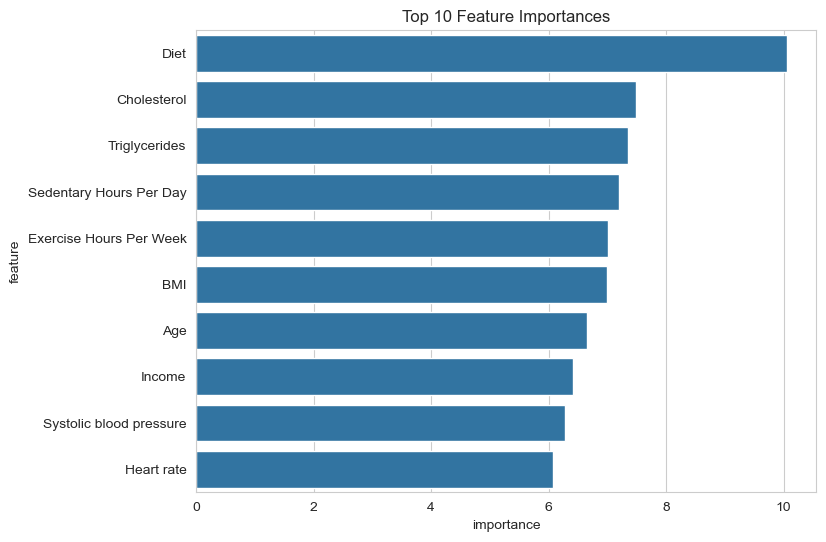

In [27]:
plt.figure(figsize=(8,6))
sns.barplot(data=feat_imp.head(10), x='importance', y='feature')
plt.title('Top 10 Feature Importances')
plt.show()

Анализ важности признаков.

Наибольшее влияние на предсказание модели оказывают признаки, связанные с образом жизни (Diet, Exercise Hours Per Week, Sedentary Hours Per Day), а также биохимические показатели (Cholesterol, Triglycerides, BMI).

Также значимыми оказались возраст и показатели артериального давления и сердечного ритма.

Полученные результаты согласуются с медицинской логикой, так как данные факторы напрямую связаны с риском сердечно-сосудистых заболеваний.

При этом наличие признака Diet с наибольшей важностью может указывать на сильную зависимость модели от поведенческих факторов.

In [29]:
joblib.dump(model, 'heart_model.pkl')

['heart_model.pkl']

Итоговый вывод.

В рамках проекта была разработана модель машинного обучения для прогнозирования риска сердечного приступа на основе медицинских и поведенческих факторов.

Были выполнены этапы анализа данных, предобработки, исследовательского анализа и построения модели классификации.

Базовая модель показала ограниченное качество по метрике F1-score, что связано с дисбалансом классов. Однако за счёт подбора порога классификации удалось значительно улучшить способность модели выявлять пациентов с повышенным риском.

Анализ важности признаков показал, что ключевыми факторами являются образ жизни, биохимические показатели и физиологические параметры, что соответствует медицинской логике.

Полученная модель может быть использована в задачах предварительной оценки риска, где важно выявление потенциально опасных случаев.

In [31]:
# Получение предсказаний на тестовой выборке и сохранение результатов
test_raw = pd.read_csv('data/heart_test.csv')

threshold = 0.3
proba_test = model.predict_proba(X_test)[:, 1]
preds_test = (proba_test >= threshold).astype(int)

submission = pd.DataFrame({
    'id': test_raw['id'],
    'prediction': preds_test
})

submission.to_csv('predictions/predictions.csv', index=False)

print('Файл сохранён!')
submission.head()

Файл сохранён!


,id,prediction
0,7746,1
1,4202,1
2,6632,0
3,4639,0
4,4825,1
